In [50]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pathlib as Path
import os


In [51]:
df = pd.read_csv("../data/processed/feature_store/r_schedule_feats_v0/2024_25/schedule_feats.csv")
print(df.shape)

schedule = pd.read_csv("../data/processed/schedule/2024-25/CLE/regular_season_schedule.csv")

(30, 9)


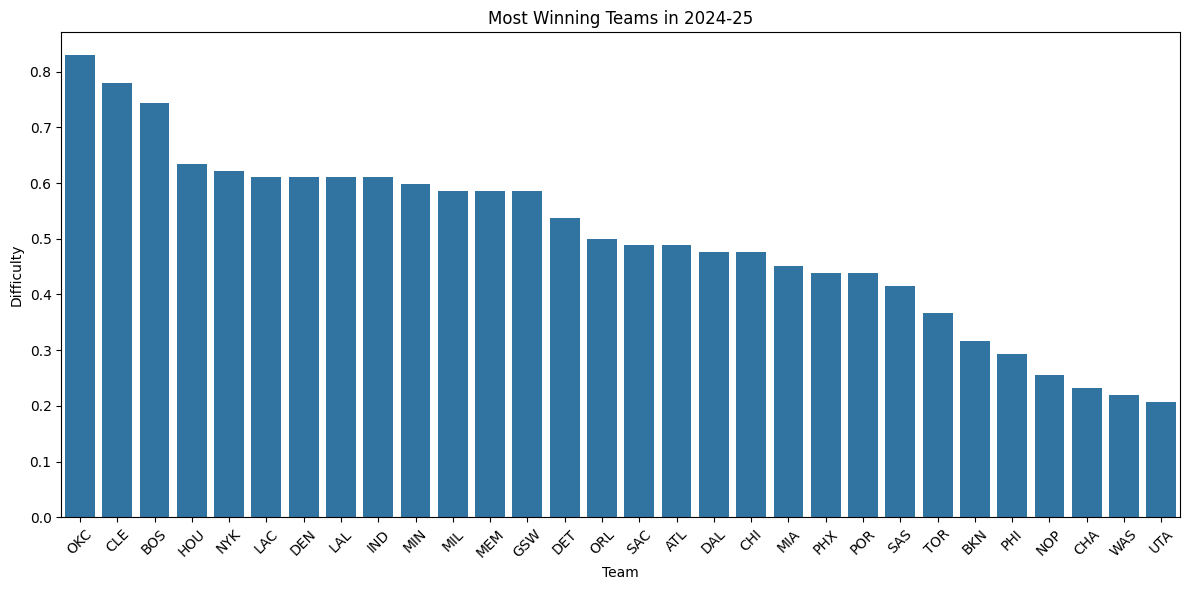

In [52]:
plot_settings = {
    'figsize': (12, 6),
    'title': 'Most Winning Teams in 2024-25',
    'xlabel': 'Team',
    'ylabel': 'Difficulty',
    'xticks_rotation': 45,
    }

win_pct = df.groupby('team')['win_pct'].mean().sort_values(ascending=False)
plt.figure(figsize=plot_settings['figsize'])
sns.barplot(x=win_pct.index, y=win_pct.values)
plt.title(plot_settings['title'])
plt.xlabel(plot_settings['xlabel'])
plt.ylabel(plot_settings['ylabel'])
plt.xticks(rotation=plot_settings['xticks_rotation'])
plt.tight_layout()


C:\Users\oukan\AppData\Local\Temp\ipykernel_3652\2066932899.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=win_pct.index, y=win_pct.values, palette=colors)


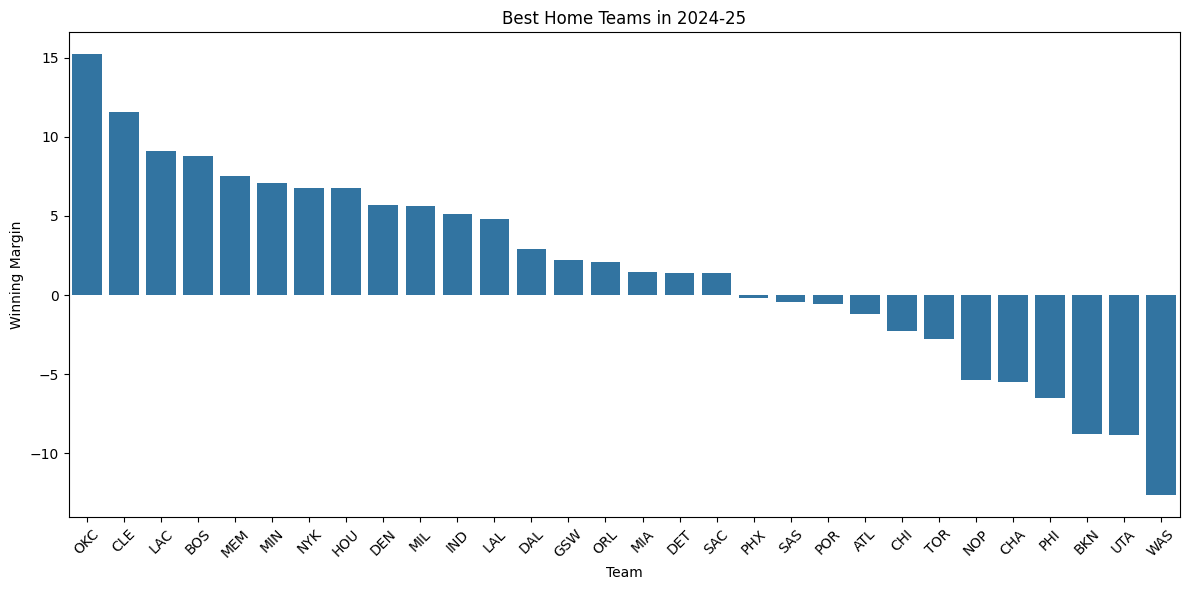

In [53]:
plot_settings = {
    'figsize': (12, 6),
    'title': 'Best Home Teams in 2024-25',
    'xlabel': 'Team',
    'ylabel': 'Winning Margin',
    'xticks_rotation': 45,
    }

default_color = sns.color_palette()[0]
colors = ['red' if val < 0 else default_color for val in win_pct.values]

win_pct = df.groupby('team')['team_hca'].mean().sort_values(ascending=False)
plt.figure(figsize=plot_settings['figsize'])
sns.barplot(x=win_pct.index, y=win_pct.values, palette=colors)
plt.title(plot_settings['title'])
plt.xlabel(plot_settings['xlabel'])
plt.ylabel(plot_settings['ylabel'])
plt.xticks(rotation=plot_settings['xticks_rotation'])
plt.tight_layout()


C:\Users\oukan\AppData\Local\Temp\ipykernel_3652\3781947434.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=win_pct.index, y=win_pct.values, palette=colors)


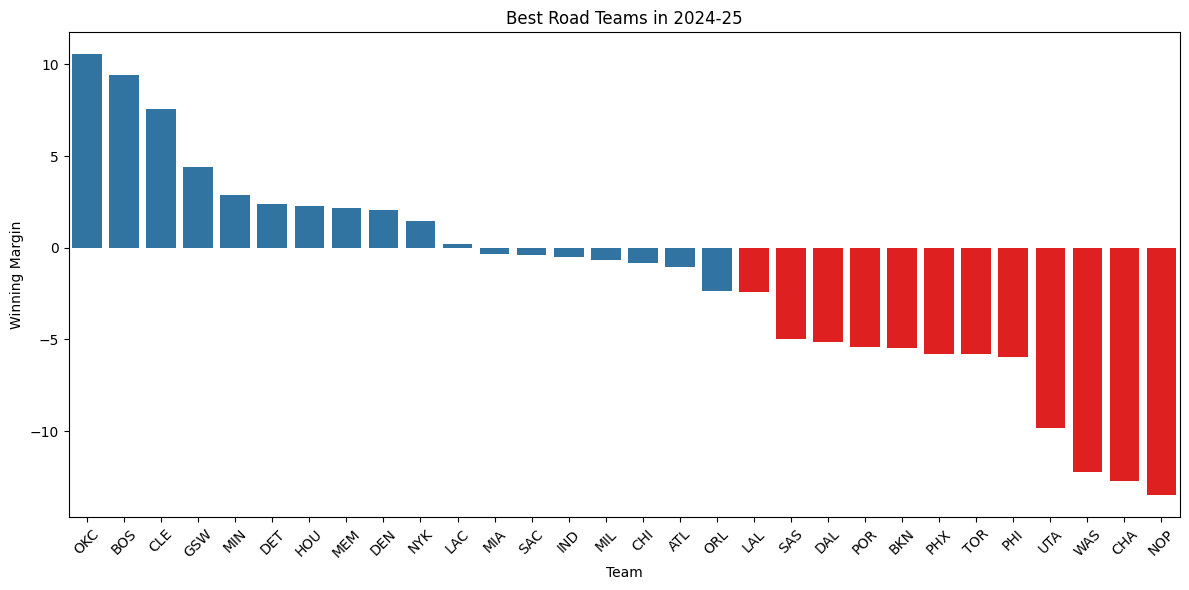

In [54]:
plot_settings = {
    'figsize': (12, 6),
    'title': 'Best Road Teams in 2024-25',
    'xlabel': 'Team',
    'ylabel': 'Winning Margin',
    'xticks_rotation': 45,
    }

default_color = sns.color_palette()[0]
colors = ['red' if val < 0 else default_color for val in win_pct.values]

win_pct = df.groupby('team')['team_rcp'].mean().sort_values(ascending=False)
plt.figure(figsize=plot_settings['figsize'])
sns.barplot(x=win_pct.index, y=win_pct.values, palette=colors)
plt.title(plot_settings['title'])
plt.xlabel(plot_settings['xlabel'])
plt.ylabel(plot_settings['ylabel'])
plt.xticks(rotation=plot_settings['xticks_rotation'])
plt.tight_layout()

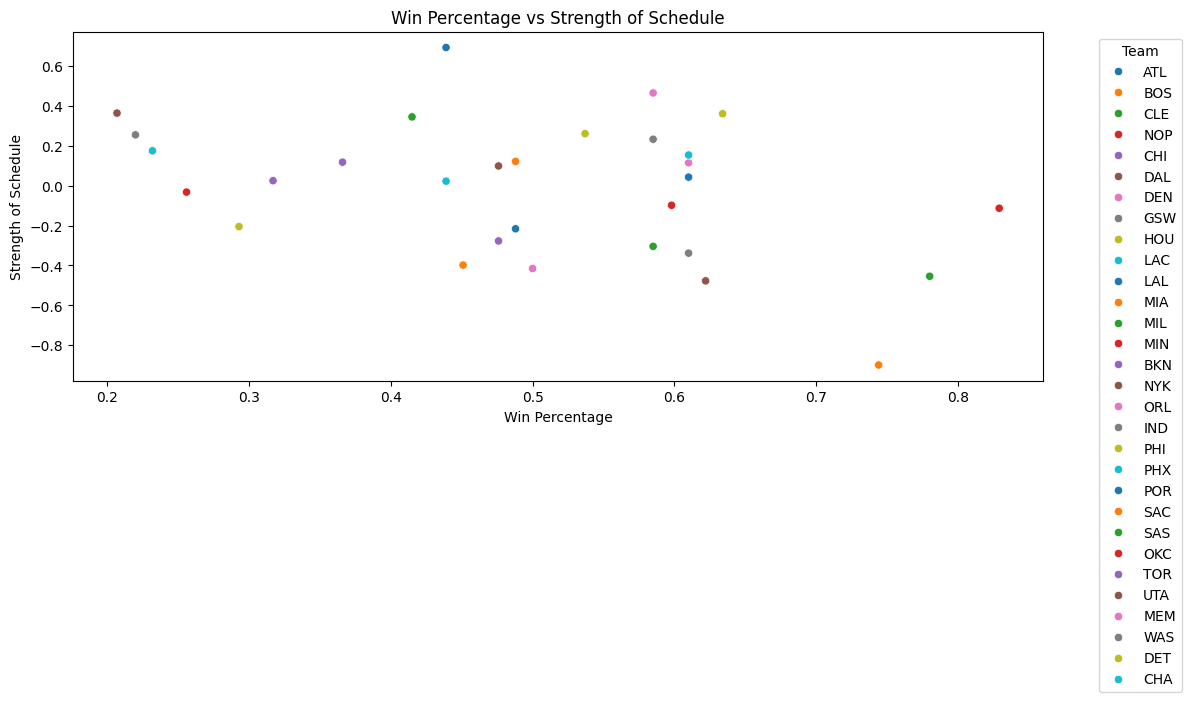

In [55]:
#scatter plot of win pct vs sos
plt.figure(figsize=(12, 6))
sns.scatterplot(x=df['win_pct'], y=df['sos_v0'], hue=df['team'], palette='tab10')
plt.title('Win Percentage vs Strength of Schedule')
plt.xlabel('Win Percentage')
plt.ylabel('Strength of Schedule')
plt.legend(title='Team', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()